<a href="https://colab.research.google.com/github/Abinaykumar-Patnala/DeepLearning/blob/main/DLLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install -U pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [ ]:
pip install keras

In [ ]:
#Sample Code: Build a Simple Neural Network with PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
# Load Iris dataset
data = load_iris()
X = data.data
y = data.target
# Convert dataset to tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1,1)
# Define model
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4,1)
    def forward(self, x):
        return self.linear(x)
model = SimpleNet()
# Loss and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
# Training loop
for epoch in range(100):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print("Final loss:", loss.item())

Final loss: 0.2103044092655182


In [ ]:
# Sample Code: Simple Neural Network with TensorFlow
import tensorflow as tf
x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,
                          input_shape=(3,))
])
model.compile(optimizer='adam',
              loss='mse')
model.fit(x, y,
          epochs=100,
          verbose=0)
print("Final loss:",
      model.evaluate(x, y))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.0347  
Final loss: 2.03470516204834


In [ ]:
# Sample Code: Same Network Using Keras (via tf.keras)
from tensorflow import keras
from tensorflow.keras import layers
x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))
model = keras.Sequential([
    layers.Dense(1,
                 input_shape=(3,))
])
model.compile(optimizer='adam',
              loss='mse')
model.fit(x, y,
          epochs=100,
          verbose=0)
print("Final loss:",
      model.evaluate(x, y))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2674 
Final loss: 2.267404794692993


weeek2


In [ ]:
#1
def AND (x1,x2):
  w1=1
  w2=1
  bias=-1.5
  activation=w1*x1+w2*x2+bias
  if activation>=0:
    return 1
  else:
    return 0
print("AND Truth Table")
for x1 in [0, 1]:
    for x2 in [0, 1]:
        print(f"{x1} AND {x2} = {AND(x1, x2)}")

def OR (x1,x2):
  w1=1
  w2=1
  bias=-0.5
  activation=w1*x1+w2*x2+bias
  if activation>=0:
    return 1
  else:
    return 0
print("\nOR Truth Table")
for x1 in [0, 1]:
    for x2 in [0, 1]:
        print(f"{x1} OR {x2} = {OR(x1, x2)}")


AND Truth Table
0 AND 0 = 0
0 AND 1 = 0
1 AND 0 = 0
1 AND 1 = 1

OR Truth Table
0 OR 0 = 0
0 OR 1 = 1
1 OR 0 = 1
1 OR 1 = 1


In [ ]:
# First layer perceptrons
def AND(x1, x2):
    w1 = 1
    w2 = 1
    bias = -1.5
    activation = w1*x1 + w2*x2 + bias
    if activation >= 0:
        return 1
    else:
        return 0
def NAND(x1, x2):
    w1 = -1
    w2 = -1
    bias = 1.5
    activation = w1*x1 + w2*x2 + bias
    if activation >= 0:
        return 1
    else:
        return 0
def OR(x1, x2):
    w1 = 1
    w2 = 1
    bias = -0.5
    activation = w1*x1 + w2*x2 + bias
    if activation >= 0:
        return 1
    else:
        return 0
# Second layer perceptron
def XOR(x1, x2):
    first_layer_output = NAND(x1, x2)
    second_layer_output = OR(x1, x2)
    output = AND(first_layer_output, second_layer_output)
    return output
# Testing the XOR function
inputs = [(0,0), (0,1), (1,0), (1,1)]
for x1, x2 in inputs:
    print(x1, x2, "->", XOR(x1, x2))

0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 0


In [ ]:
#XOR Training Using Gradient Descent
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    return x * (1 - x)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([[0], [1], [1], [0]])
np.random.seed(42)
W1 = np.random.rand(2, 2)
b1 = np.random.rand(1, 2)
W2 = np.random.rand(2, 1)
b2 = np.random.rand(1, 1)
learning_rate = 0.1
epochs = 10000
for epoch in range(epochs):
    hidden_input = np.dot(X, W1) + b1
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, W2) + b2
    y_pred = sigmoid(final_input)
    error = y - y_pred
    loss = np.mean(error ** 2)
    d_output = error * sigmoid_derivative(y_pred)
    d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)
    W2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
    W1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
print("\nXOR Predictions after Training:")
for i in range(len(X)):
    print(X[i], "->", round(y_pred[i][0]))

Epoch 0, Loss: 0.3247
Epoch 1000, Loss: 0.2406
Epoch 2000, Loss: 0.1960
Epoch 3000, Loss: 0.1207
Epoch 4000, Loss: 0.0305
Epoch 5000, Loss: 0.0125
Epoch 6000, Loss: 0.0074
Epoch 7000, Loss: 0.0051
Epoch 8000, Loss: 0.0038
Epoch 9000, Loss: 0.0031

XOR Predictions after Training:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


In [ ]:
from IPython.display import Image
Image(url="https://miro.medium.com/max/1200/1*iWQzxhVlvadk6VAJjsgXgg.png", width=800, height=500)

#regularization

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# Load dataset
data = load_iris()
X = data.data
y = to_categorical(data.target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Model with L2 regularization
model = models.Sequential([
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01),
                 input_shape=(4,)),
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))
loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

In [ ]:
#Dropout
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
# Load dataset
data = load_iris()
X = data.data
y = to_categorical(data.target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2667 - loss: 1.9240
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3000 - loss: 1.8464 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3917 - loss: 1.4779 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3667 - loss: 1.3940 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3833 - loss: 1.3112  
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3417 - loss: 1.2092 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3917 - loss: 1.1888 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4417 - loss: 1.3403 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3167 - loss: 1.2504 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4083 - loss: 1.2292 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3917 - loss: 1.1671 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4667 - loss: 1.1087 
Epoch 13/50


In [ ]:
#Early Stopping
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
data = load_iris()
X = data.data
y = to_categorical(data.target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
model.fit(X_train, y_train,
          epochs=100,
          validation_data=(X_test, y_test),
          callbacks=[early_stop])
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.3000 - loss: 1.3620 - val_accuracy: 0.4667 - val_loss: 1.0114
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3000 - loss: 1.0989 - val_accuracy: 0.5000 - val_loss: 0.9919
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3750 - loss: 0.9662 - val_accuracy: 0.4667 - val_loss: 1.0166
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6583 - loss: 0.9163 - val_accuracy: 0.5333 - val_loss: 1.0134
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7000 - loss: 0.8662 - val_accuracy: 0.5333 - val_loss: 0.9752
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7000 - loss: 0.8222 - val_accuracy: 0.5333 - val_loss: 0.9140
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7000 - loss: 0.7787 - val_accuracy: 0.5333 - val_loss: 0.8490
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7083 - loss: 0.7315 - val_accuracy: 0.5667 - val_loss: 0.7937
Epo

In [ ]:
#Adding noise to the input
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
data = load_iris()
X = data.data
y = to_categorical(data.target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
noise_factor = 0.1
X_train_noisy = X_train + noise_factor * np.random.normal(size=X_train.shape)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(X_train_noisy, y_train, epochs=50)
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3333 - loss: 1.3487
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3333 - loss: 1.1614
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3333 - loss: 1.0339
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4750 - loss: 0.9601
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6333 - loss: 0.9131
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6750 - loss: 0.8728
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8167 - loss: 0.8319 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8583 - loss: 0.7907 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8667 - loss: 0.7521
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8417 - loss: 0.7158
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8000 - loss: 0.6862
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.6595
E

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
data = load_iris()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model1 = LogisticRegression(max_iter=200)
model2 = DecisionTreeClassifier()
ensemble = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2)],
    voting='hard'
)
ensemble.fit(X_train, y_train)
y_pred = ensemble.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)
print("Dataset augmentation generator created")

Dataset augmentation generator created


#CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.9573 - loss: 0.1414 - val_accuracy: 0.9849 - val_loss: 0.0464
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9853 - loss: 0.0461 - val_accuracy: 0.9841 - val_loss: 0.0443
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9900 - loss: 0.0319 - val_accuracy: 0.9897 - val_loss: 0.0314
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9921 - loss: 0.0252 - val_accuracy: 0.9908 - val_loss: 0.0278
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accuracy: 0.9918 - val_loss: 0.0259
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9918 - loss: 0.0259
Test Accuracy: 0.9918000102043152


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
def build_model():
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model
optimizers = {
    "BGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "MiniBatch GD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Nesterov": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "Adagrad": tf.keras.optimizers.Adagrad(learning_rate=0.01),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adadelta": tf.keras.optimizers.Adadelta(),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}
results = {}
for opt_name, optimizer in optimizers.items():
    print("Training with:", opt_name)
    model = build_model()
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    if opt_name == "BGD":
        batch_size = len(X_train)
    elif opt_name == "SGD":
        batch_size = 32
    elif opt_name == "MiniBatch GD":
        batch_size = 64
    else:
        batch_size = 64
    model.fit(X_train, y_train,
              epochs=5,
              batch_size=batch_size,
              verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    results[opt_name] = test_accuracy
    print("Accuracy:", test_accuracy)
    print()
print("Final Accuracy Comparison")
for opt, acc in results.items():
    print(opt, "Accuracy:", acc)

Training with: BGD
Accuracy: 0.20999999344348907

Training with: SGD
Accuracy: 0.9517999887466431

Training with: MiniBatch GD
Accuracy: 0.9358000159263611

Training with: Momentum
Accuracy: 0.9732000231742859

Training with: Nesterov
Accuracy: 0.972599983215332

Training with: Adagrad
Accuracy: 0.9524000287055969

Training with: RMSProp
Accuracy: 0.9751999974250793

Training with: Adadelta
Accuracy: 0.4848000109195709

Training with: Adam
Accuracy: 0.9746999740600586

Final Accuracy Comparison
BGD Accuracy: 0.20999999344348907
SGD Accuracy: 0.9517999887466431
MiniBatch GD Accuracy: 0.9358000159263611
Momentum Accuracy: 0.9732000231742859
Nesterov Accuracy: 0.972599983215332
Adagrad Accuracy: 0.9524000287055969
RMSProp Accuracy: 0.9751999974250793
Adadelta Accuracy: 0.4848000109195709
Adam Accuracy: 0.9746999740600586


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


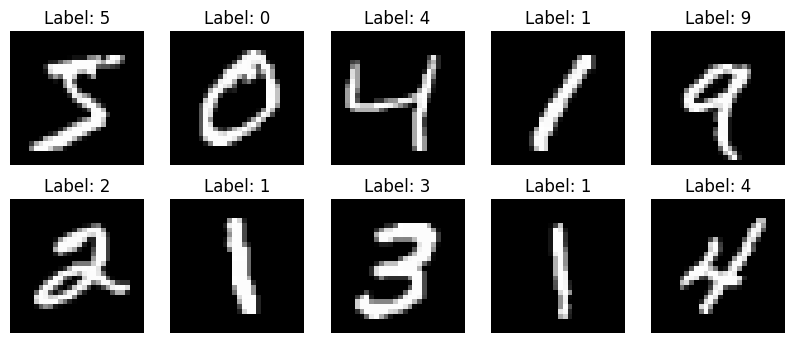

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.8867 - loss: 0.3980 - val_accuracy: 0.9465 - val_loss: 0.1758
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 55ms/step - accuracy: 0.9527 - loss: 0.1530 - val_accuracy: 0.9649 - val_loss: 0.1185
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.9698 - loss: 0.0996 - val_accuracy: 0.9743 - val_loss: 0.0856
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.9780 - loss: 0.0739 - val_accuracy: 0.9768 - val_loss: 0.0798
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9826 - loss: 0.0579 - val_accuracy: 0.9802 - val_loss: 0.0663
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9853 - loss: 0.0474 - val_accuracy: 0.9804 - val_loss: 0.0665
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.9877 - loss: 0.0401 - val_accuracy: 0.9825 - val_loss: 0.0616
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.9898 - loss: 0.0328 - 

In [ ]:
#Import Necessary Libraries
import keras
import keras.utils
from keras import datasets, layers, models
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
import matplotlib.pyplot as plt
#Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
#Visualize The Training Data
plt.figure(figsize=(10, 4))  # Set The size Of The Figure
for i in range(10):
    plt.subplot(2, 5, i + 1)  # Make subplots for 10 images
    plt.imshow(x_train[i], cmap='gray')  # Display The grayscale images
    plt.title(f"Label: {y_train[i]}")  # Add labels
    plt.axis('off')  # Axis Labels Turned Off
plt.show()  # Displaying the plot
#Data Processing
#Split The Data Into Training And Validation Set
#Here, we will split the data into the training and validation set.
# Consider The First 50000 samples As The Training Dataset
x_train_main = x_train[:50000]
y_train_main = y_train[:50000]
# Conside The Last 10000 Samples AS The Validation Dataset
x_val = x_train[50000:]
y_val = y_train[50000:]
#Normalize the Data
x_train_main = x_train_main / 255.0
x_val=x_val/255.0
x_test = x_test / 255.0
#Reshape data
#Change the shape of the arrays to include the color channel of the images. Since the images are grayscale, the color channel is 1.
x_train_main = x_train_main.reshape(50000, 28, 28, 1)
x_val = x_val.reshape(10000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)
#One Hot Encoding
#Perform one-hot encoding to convert categorical data into binary vectors.
#Each element in the binary vector corresponds to a class, and only one element is 1, while the rest are 0.
#For example, if there are 10 classes and the label is 3, the one-hot encoded vector would be [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].
y_train_main = keras.utils.to_categorical(y_train_main, 10)
y_val = keras.utils.to_categorical(y_val, 10)
y_test = keras.utils.to_categorical(y_test, 10)
#Build LeNet5 Model
#Create An Instance of Sequential Class.
LeNet5_Model=Sequential()
# Add First Convolutional Layer
LeNet5_Model.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))
# Add First Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))
# Add Second Convolutional Layer
LeNet5_Model.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
# Add Second Average Pooling Layer
LeNet5_Model.add(AveragePooling2D((2, 2)))
# Flatten The Layer
LeNet5_Model.add(Flatten())
# Add Dense Layer
LeNet5_Model.add(Dense(120, activation='tanh'))
LeNet5_Model.add(Dense(84, activation='tanh'))
LeNet5_Model.add(Dense(10, activation='softmax'))
#Compile The Model
LeNet5_Model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
#Check Model Summary
LeNet5_Model.summary()
LeNet5_Model.fit(x_train_main, y_train_main, epochs=20, batch_size=128, validation_data=(x_val, y_val))
test_loss, test_acc = LeNet5_Model.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

In [ ]:
import keras
from keras import datasets, layers, models
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)
x_train_main, x_val = x_train[:50000], x_train[50000:]
y_train_main, y_val = y_train[:50000], y_train[50000:]
def plot_history(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.legend(['Train','Val'])
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.legend(['Train','Val'])
    plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 64s 153ms/step - accuracy: 0.8900 - loss: 0.3805 - val_accuracy: 0.9483 - val_loss: 0.1765
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 97ms/step - accuracy: 0.9553 - loss: 0.1470 - val_accuracy: 0.9665 - val_loss: 0.1141
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.9709 - loss: 0.0963 - val_accuracy: 0.9751 - val_loss: 0.0812
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9781 - loss: 0.0709 - val_accuracy: 0.9769 - val_loss: 0.0779
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 73ms/step - accuracy: 0.9833 - loss: 0.0556 - val_accuracy: 0.9796 - val_loss: 0.0682
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9864 - loss: 0.0444 - val_accuracy: 0.9827 - val_loss: 0.0615
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9890 - loss: 0.0354 - val_accuracy: 0.9804 - val_loss: 0.0661
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.9907 - loss: 0.0292 -

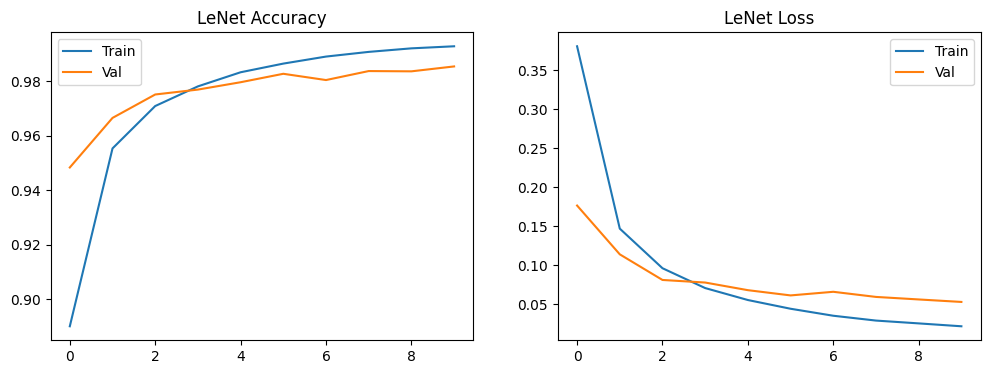

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9845 - loss: 0.0503
LeNet Accuracy: 0.984499990940094


In [ ]:
model = models.Sequential([
    layers.Conv2D(6,(5,5),activation='tanh',padding='same',input_shape=(28,28,1)),
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Conv2D(16,(5,5),activation='tanh'),
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(120,activation='tanh'),
    layers.Dense(84,activation='tanh'),
    layers.Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train_main,y_train_main,epochs=10,batch_size=128,
validation_data=(x_val,y_val))
plot_history(history,"LeNet")
test_loss,test_acc = model.evaluate(x_test,y_test)
print("LeNet Accuracy:",test_acc)

In [ ]:
import torch.nn as nn
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,6,5,padding=2),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6,16,5,padding=2),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Flatten(),
            nn.Linear(16*8*8,120),
            nn.ReLU(),
            nn.Linear(120,84),
            nn.ReLU(),
            nn.Linear(84,10)
        )
    def forward(self,x):
        return self.net(x)

In [ ]:
model = models.Sequential([
    layers.Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(28,28,1)),
    layers.MaxPooling2D(),
    layers.Conv2D(192,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(384,(3,3),activation='relu'),
    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train_main,y_train_main,epochs=10,batch_size=128,
validation_data=(x_val,y_val))
plot_history(history,"AlexNet")
print("AlexNet Accuracy:",model.evaluate(x_test,y_test)[1])

In [ ]:
model = models.Sequential([
    layers.Conv2D(96,(3,3),activation='relu',padding='same',input_shape=(28,28,1)),
    layers.MaxPooling2D(),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(384,(3,3),activation='relu'),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train_main,y_train_main,epochs=10,batch_size=128,
validation_data=(x_val,y_val))
plot_history(history,"ZFNet")
print("ZFNet Accuracy:",model.evaluate(x_test,y_test)[1])

In [ ]:
model = models.Sequential([
    layers.Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(28,28,1)),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train_main,y_train_main,epochs=10,batch_size=128,
validation_data=(x_val,y_val))
plot_history(history,"VGGNet")
print("VGG Accuracy:",model.evaluate(x_test,y_test)[1])

In [ ]:
input_layer = layers.Input(shape=(28,28,1))
conv = layers.Conv2D(64,(3,3),padding='same',activation='relu')(input_layer)
b1 = layers.Conv2D(16,(1,1),activation='relu')(conv)
b2 = layers.Conv2D(24,(3,3),padding='same',activation='relu')(conv)
b3 = layers.Conv2D(24,(5,5),padding='same',activation='relu')(conv)
concat = layers.concatenate([b1,b2,b3])
pool = layers.GlobalAveragePooling2D()(concat)
output = layers.Dense(10,activation='softmax')(pool)
model = models.Model(inputs=input_layer,outputs=output)
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train_main,y_train_main,epochs=10,batch_size=128,
validation_data=(x_val,y_val))
plot_history(history,"GoogLeNet")
print("GoogLeNet Accuracy:",model.evaluate(x_test,y_test)[1])

In [ ]:
input_layer = layers.Input(shape=(28,28,1))
x = layers.Conv2D(64,(3,3),padding='same',activation='relu')(input_layer)
shortcut = x
x = layers.Conv2D(64,(3,3),padding='same',activation='relu')(x)
x = layers.Conv2D(64,(3,3),padding='same')(x)
x = layers.add([x,shortcut])
x = layers.Activation('relu')(x)
x = layers.GlobalAveragePooling2D()(x)
output = layers.Dense(10,activation='softmax')(x)
model = models.Model(inputs=input_layer,outputs=output)
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
history = model.fit(x_train_main,y_train_main,epochs=10,batch_size=128,
validation_data=(x_val,y_val))
plot_history(history,"ResNet")
print("ResNet Accuracy:",model.evaluate(x_test,y_test)[1])

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 75.6MB/s]


In [ ]:
#1
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
    def forward(self, x):
        x = x.view(-1, 32*32*3)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x
model = NeuralNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total)

100%|██████████| 170M/170M [00:02<00:00, 67.7MB/s]


Epoch 1, Loss: 1276.6340
Epoch 2, Loss: 1117.7523
Epoch 3, Loss: 1030.3740
Epoch 4, Loss: 956.9293
Epoch 5, Loss: 893.2859
Accuracy: 53.0


In [ ]:
#2
import tensorflow as tf
from tensorflow.keras import layers, models
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10)
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 37ms/step - accuracy: 0.3282 - loss: 1.8567 - val_accuracy: 0.3787 - val_loss: 1.7116
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.4044 - loss: 1.6617 - val_accuracy: 0.4297 - val_loss: 1.6020
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4342 - loss: 1.5797 - val_accuracy: 0.4260 - val_loss: 1.5920
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.4498 - loss: 1.5366 - val_accuracy: 0.4531 - val_loss: 1.5327
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.4608 - loss: 1.5077 - val_accuracy: 0.4587 - val_loss: 1.5058
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4587 - loss: 1.5058
Accuracy: 0.4587000012397766


In [ ]:
#3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
model = Sequential([
    Flatten(input_shape=(32,32,3)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3130 - loss: 1.8906 - val_accuracy: 0.3458 - val_loss: 1.7888
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3864 - loss: 1.7029 - val_accuracy: 0.4125 - val_loss: 1.6481
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4188 - loss: 1.6231 - val_accuracy: 0.3954 - val_loss: 1.6718
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.4352 - loss: 1.5724 - val_accuracy: 0.4216 - val_loss: 1.6113
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.4500 - loss: 1.5328 - val_accuracy: 0.4433 - val_loss: 1.5563


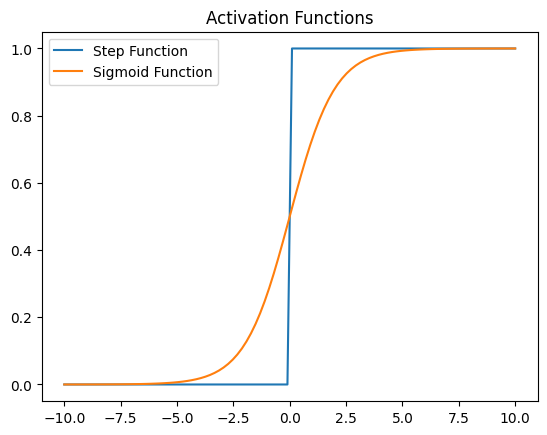

In [ ]:
#4
import numpy as np
import matplotlib.pyplot as plt
def step(x):
    return np.where(x >= 0, 1, 0)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
x = np.linspace(-10, 10, 100)
step_y = step(x)
sigmoid_y = sigmoid(x)
plt.plot(x, step_y, label="Step Function")
plt.plot(x, sigmoid_y, label="Sigmoid Function")
plt.legend()
plt.title("Activation Functions")
plt.show()

In [ ]:
#5
import numpy as np
X = np.array([[0,0],[0,1],[1,0],[1,1]])
weights_and = np.array([1,1])
bias_and = -1.5
weights_or = np.array([1,1])
bias_or = -0.5
def perceptron(x, w, b):
    return 1 if np.dot(x, w) + b >= 0 else 0
print("AND Gate")
for x in X:
    print(x, perceptron(x, weights_and, bias_and))
print("\nOR Gate")
for x in X:
    print(x, perceptron(x, weights_or, bias_or))

AND Gate
[0 0] 0
[0 1] 0
[1 0] 0
[1 1] 1

OR Gate
[0 0] 0
[0 1] 1
[1 0] 1
[1 1] 1


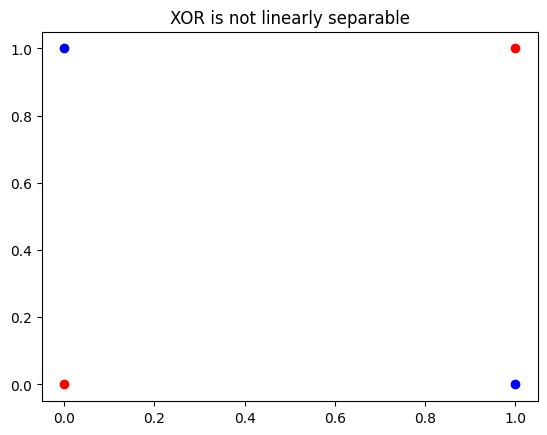

In [ ]:
#6
import matplotlib.pyplot as plt
X = [[0,0],[0,1],[1,0],[1,1]]
y = [0,1,1,0]
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red')
    else:
        plt.scatter(X[i][0], X[i][1], color='blue')
plt.title("XOR is not linearly separable")
plt.show()

In [ ]:
#7
from sklearn.neural_network import MLPClassifier
X = [[0,0],[0,1],[1,0],[1,1]]
y = [0,1,1,0]
model = MLPClassifier(hidden_layer_sizes=(4,), activation='relu', max_iter=2000)
model.fit(X, y)
print("Predictions:", model.predict(X))

Predictions: [1 1 0 0]


In [ ]:
#8
import pandas as pd
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
data = {
    'actor':[1,0,1,0,1],
    'thriller':[1,1,0,0,1],
    'director':[1,0,1,0,1],
    'rating':[0.9,0.6,0.8,0.3,0.95],
    'like':[1,0,1,0,1]
}
df = pd.DataFrame(data)
X = df.drop('like', axis=1)
y = df['like']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = Perceptron(max_iter=1000)
model.fit(X_train, y_train)
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 1.0


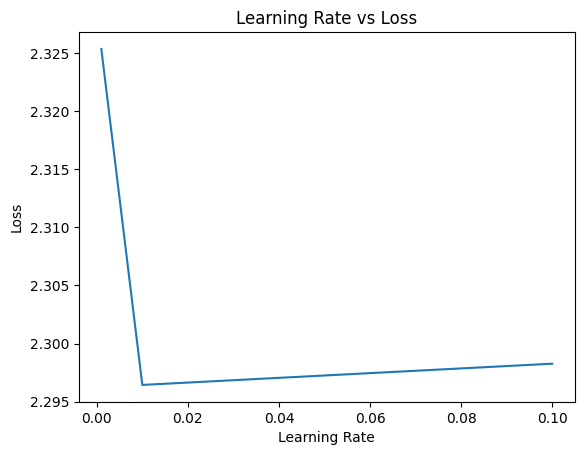

In [ ]:
#9
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 10)
    def forward(self, x):
        x = x.view(-1, 3072)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)
learning_rates = [0.1, 0.01, 0.001]
loss_values = []
for lr in learning_rates:
    model = MLP()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_values.append(loss.item())
        break
plt.plot(learning_rates, loss_values)
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs Loss")
plt.show()

In [ ]:
#10
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
for epoch in range(5):
    total_loss = 0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 1601.050352692604
Epoch 2, Loss: 1374.1744853258133
Epoch 3, Loss: 1281.6081373691559
Epoch 4, Loss: 1221.6365106105804
Epoch 5, Loss: 1174.016741514206


In [ ]:
#11
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = Perceptron(max_iter=1000, eta0=0.1)
model.fit(X_train, y_train)
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.7166666666666667
Test Accuracy: 0.8


In [ ]:
#12
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
for epoch in range(5):
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
print("Training completed")

Training completed


In [ ]:
#13
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))])
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
    def forward(self, x):
        x = x.view(-1, 3072)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)
model = DeepMLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
for epoch in range(5):
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

100%|██████████| 170M/170M [00:04<00:00, 39.4MB/s]


Epoch 1, Loss: 2610.0293
Epoch 2, Loss: 2280.1040
Epoch 3, Loss: 2106.4339
Epoch 4, Loss: 1973.1436
Epoch 5, Loss: 1854.9769


In [ ]:
#14
import torch
import torch.nn as nn
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3072, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = x.view(-1, 3072)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
optimizers = {
    "SGD": torch.optim.SGD,
    "Adam": torch.optim.Adam,
    "RMSprop": torch.optim.RMSprop
}
for name, opt_fn in optimizers.items():
    print(f"\nTraining with {name}")
    model = MLP().to(device)
    optimizer = opt_fn(model.parameters(), lr=0.001 if name != "SGD" else 0.01)
    for epoch in range(2):
        total_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"{name} Epoch {epoch+1}, Loss: {total_loss:.4f}")


Training with SGD
SGD Epoch 1, Loss: 2799.4530
SGD Epoch 2, Loss: 2469.1342

Training with Adam
Adam Epoch 1, Loss: 2581.5739
Adam Epoch 2, Loss: 2305.9766

Training with RMSprop
RMSprop Epoch 1, Loss: 2607.3146
RMSprop Epoch 2, Loss: 2299.5735


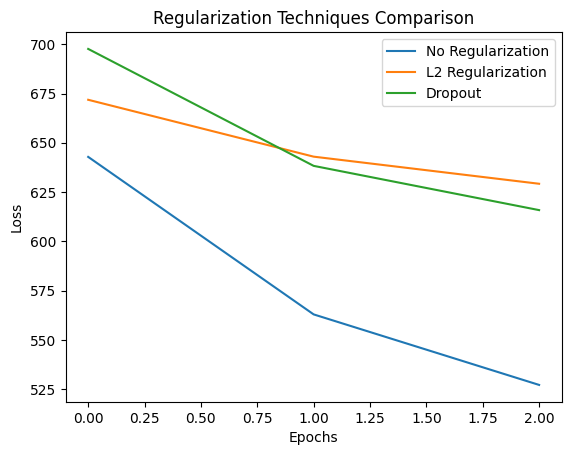

In [ ]:
#15
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
class BaseMLP(nn.Module):
    def __init__(self, dropout=False):
        super().__init__()
        self.fc1 = nn.Linear(3072, 512)
        self.dropout = nn.Dropout(0.5) if dropout else None
        self.fc2 = nn.Linear(512, 10)
    def forward(self, x):
        x = x.view(-1, 3072)
        x = torch.relu(self.fc1(x))
        if self.dropout:
            x = self.dropout(x)
        return self.fc2(x)
def train_model(model, optimizer):
    criterion = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(3):
        total_loss = 0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss)
    return losses
model_base = BaseMLP()
opt_base = optim.Adam(model_base.parameters(), lr=0.001)
loss_base = train_model(model_base, opt_base)
model_l2 = BaseMLP()
opt_l2 = optim.Adam(model_l2.parameters(), lr=0.001, weight_decay=0.01)
loss_l2 = train_model(model_l2, opt_l2)
model_dropout = BaseMLP(dropout=True)
opt_dropout = optim.Adam(model_dropout.parameters(), lr=0.001)
loss_dropout = train_model(model_dropout, opt_dropout)
plt.plot(loss_base, label="No Regularization")
plt.plot(loss_l2, label="L2 Regularization")
plt.plot(loss_dropout, label="Dropout")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Regularization Techniques Comparison")
plt.legend()
plt.show()

Training Done


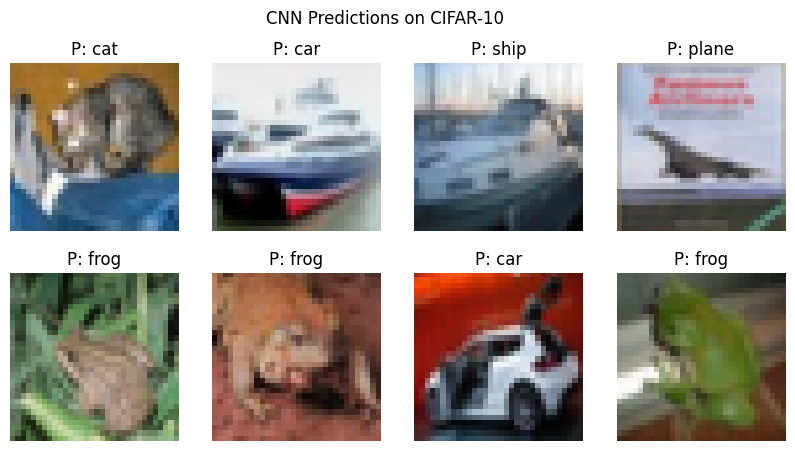

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=8, shuffle=False)
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 6 * 6)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(3):
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
print("Training Done")
dataiter = iter(testloader)
images, labels = next(dataiter)
outputs = model(images)
_, predicted = torch.max(outputs, 1)
images = images / 2 + 0.5
npimg = images.numpy()
fig, axes = plt.subplots(2, 4, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.transpose(npimg[i], (1,2,0)))
    ax.set_title(f"P: {classes[predicted[i]]}")
    ax.axis('off')
plt.suptitle("CNN Predictions on CIFAR-10")
plt.show()

In [ ]:
#17
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True
)
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)
model = ImprovedCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
for epoch in range(5):
    model.train()
    total_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
print("CNN Training Completed")

Epoch 1, Loss: 1010.9685
Epoch 2, Loss: 716.1647


In [ ]:
#18
import torchvision.models as models
import torch.nn as nn
model_vgg = models.vgg16(pretrained=True)
model_alex = models.alexnet(pretrained=True)
model_vgg.classifier[6] = nn.Linear(4096, 10)
model_alex.classifier[6] = nn.Linear(4096, 10)
print("Modified for CIFAR-10")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:10<00:00, 54.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 144MB/s]


Modified for CIFAR-10


In [ ]:
#19
import torchvision.models as models
import torch.nn as nn
model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT, aux_logits=True)
model.fc = nn.Linear(1024, 10)
model.aux1.fc2 = nn.Linear(1024, 10)
model.aux2.fc2 = nn.Linear(1024, 10)
print("Fixed GoogLeNet with aux")

Fixed GoogLeNet with aux


/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [ ]:
#20
model = models.resnet18(pretrained=True)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

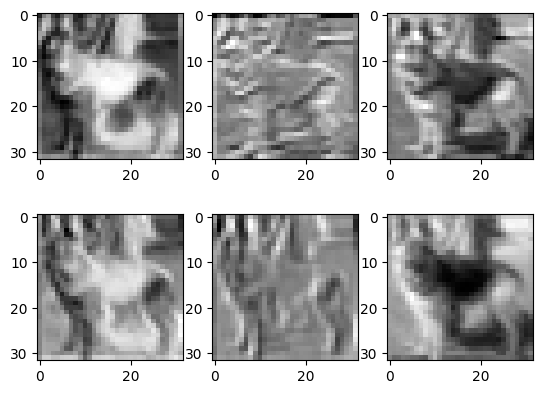

In [ ]:
#21
import matplotlib.pyplot as plt

dataiter = iter(trainloader)
images, labels = next(dataiter)

model = ImprovedCNN()
out = model.conv1(images)
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(out[0][i].detach().numpy(), cmap='gray')
plt.show()

In [ ]:
#22
images.requires_grad = True

output = model(images)
loss = output.mean()
loss.backward()
print(images.grad.shape)

torch.Size([64, 3, 32, 32])


torch.Size([64, 10])


Epoch 1, Loss: 3.0301
Training Done


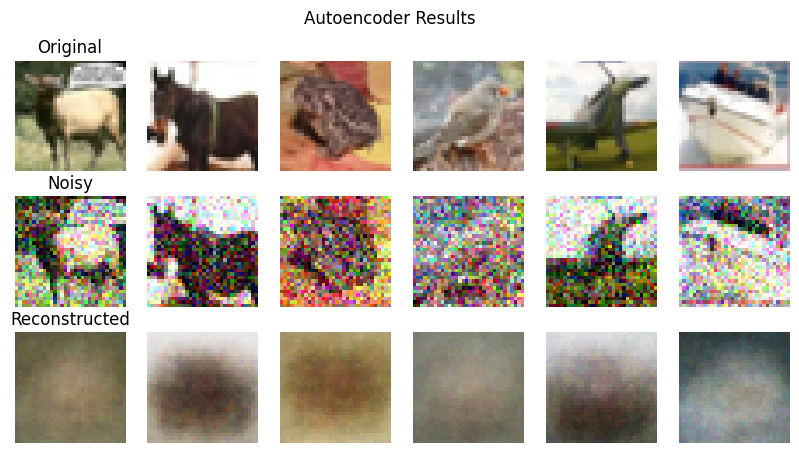

In [ ]:
# Q23: Autoencoder (FAST VERSION)
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor()
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
subset_size = 2000
trainset = torch.utils.data.Subset(trainset, range(subset_size))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(-1, 3072)
        x = self.encoder(x)
        x = self.decoder(x)
        return x
model = Autoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
for epoch in range(1):
    total_loss = 0
    for images, _ in trainloader:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images.view(-1, 3072))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
print("Training Done")
dataiter = iter(trainloader)
images, _ = next(dataiter)
images = images.to(device)
noisy = images + 0.2 * torch.randn_like(images)
with torch.no_grad():
    reconstructed = model(noisy)
reconstructed = reconstructed.view(-1, 3, 32, 32)
images = images.cpu()
noisy = noisy.cpu()
reconstructed = reconstructed.cpu()
fig, axes = plt.subplots(3, 6, figsize=(10,5))
for i in range(6):
    axes[0][i].imshow(images[i].permute(1,2,0))
    axes[0][i].axis('off')
    axes[1][i].imshow(noisy[i].permute(1,2,0))
    axes[1][i].axis('off')
    axes[2][i].imshow(reconstructed[i].permute(1,2,0))
    axes[2][i].axis('off')
axes[0][0].set_title("Original")
axes[1][0].set_title("Noisy")
axes[2][0].set_title("Reconstructed")
plt.suptitle("Autoencoder Results")
plt.show()

In [ ]:
print(reconstructed.shape)

torch.Size([64, 10])


In [ ]:
#24
# Undercomplete: smaller latent (128)
# Overcomplete: larger latent (2048)
import torch.nn as nn
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(3072, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, 3072)
        )

In [ ]:
#25
optimizer = torch.optim.Adam(model.parameters(), weight_decay=0.01)

In [ ]:
#26
for epoch in range(5):
    total_loss = 0
    for images, _ in trainloader:
        images = images.to(device)
        noisy = images + 0.2 * torch.randn_like(images)
        noisy = torch.clamp(noisy, 0., 1.)
        optimizer.zero_grad()
        outputs = model(noisy)
        loss = criterion(outputs, images.view(-1, 3072))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 213.4018
Epoch 2, Loss: 230.6262
Epoch 3, Loss: 231.4631
Epoch 4, Loss: 231.5216
Epoch 5, Loss: 231.4882


In [ ]:
#27
from sklearn.decomposition import PCA

data = images.view(-1,3072).detach().numpy()
pca = PCA(n_components=128)
pca.fit(data)
print("PCA done")

In [ ]:
#28
# Add L1 penalty
l1_lambda = 0.001
l1_norm = sum(p.abs().sum() for p in model.parameters())
loss = loss + l1_lambda * l1_norm

In [ ]:
#29
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(10, 20, batch_first=True)
        self.fc = nn.Linear(20, 10)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out)

In [ ]:
#30
lstm = nn.LSTM(10, 20, batch_first=True)
gru = nn.GRU(10, 20, batch_first=True)

In [ ]:
#31
encoder = nn.LSTM(10, 20, batch_first=True)
decoder = nn.LSTM(20, 10, batch_first=True)

In [ ]:
#32
import torch.nn.functional as F

scores = torch.randn(1,5)
attention = F.softmax(scores, dim=1)
print(attention)